In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [3]:
from google.colab import files
uploaded = files.upload()

Saving housing_price_dataset.csv to housing_price_dataset (1).csv


In [4]:
df = pd.read_csv("housing_price_dataset.csv")

In [5]:
df.head()

,property_id,city,locality,locality_tier,property_type,bhk,bathrooms,balconies,built_up_area,carpet_area,...,power_backup,lift_available,maintenance_fee_monthly,distance_to_city_center_km,distance_to_metro_km,nearby_schools,nearby_hospitals,transaction_type,price_in_lakhs,price_category
0,PROP-000001,Bangalore,HSR Layout,Standard,Apartment,4,4,1,1570,1361,...,1,0,3094,11.6,3.5,3,1,New,102.34,Low
1,PROP-000002,Mumbai,Powai,Standard,Row House,2,1,1,908,778,...,1,1,3893,24.2,1.3,3,2,Resale,71.48,Low
2,PROP-000003,Bangalore,Indiranagar,Premium,Independent House,3,3,2,1784,1568,...,1,1,7038,5.0,0.1,2,1,Resale,245.57,High
3,PROP-000004,Mumbai,Powai,Standard,Independent House,4,4,2,2318,2011,...,0,1,3569,11.9,7.9,2,0,New,122.95,Low
4,PROP-000005,Bangalore,Electronic City,Standard,Apartment,3,4,2,988,840,...,1,1,2628,11.4,7.2,1,0,Resale,64.71,Low


In [6]:
df.shape

(50000, 30)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 30 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   property_id                 50000 non-null  object 
 1   city                        50000 non-null  object 
 2   locality                    50000 non-null  object 
 3   locality_tier               50000 non-null  object 
 4   property_type               50000 non-null  object 
 5   bhk                         50000 non-null  int64  
 6   bathrooms                   50000 non-null  int64  
 7   balconies                   50000 non-null  int64  
 8   built_up_area               50000 non-null  int64  
 9   carpet_area                 50000 non-null  int64  
 10  floor_number                50000 non-null  int64  
 11  total_floors                50000 non-null  int64  
 12  floor_category              50000 non-null  object 
 13  facing                      500

In [8]:
df.isnull().sum()

,0
property_id,0
city,0
locality,0
locality_tier,0
property_type,0
bhk,0
bathrooms,0
balconies,0
built_up_area,0
carpet_area,0


In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df.describe()

,bhk,bathrooms,balconies,built_up_area,carpet_area,floor_number,total_floors,property_age,parking_spaces,security_score,gym_available,swimming_pool,power_backup,lift_available,maintenance_fee_monthly,distance_to_city_center_km,distance_to_metro_km,nearby_schools,nearby_hospitals,price_in_lakhs
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.00000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,3.152220,3.363320,1.688440,1573.280760,1321.453680,9.321400,14.435200,6.512000,1.91362,6.004076,0.414860,0.299840,0.684920,0.838180,3984.119580,11.519852,2.506840,3.115700,1.903580,166.754386
std,1.216009,1.330742,1.236107,670.323353,564.290797,8.704547,8.814554,6.884051,1.44929,1.606905,0.492703,0.458192,0.464552,0.368289,1640.950213,5.434226,2.484553,1.899038,1.469465,104.716850
min,1.000000,1.000000,0.000000,300.000000,240.000000,0.000000,1.000000,0.000000,0.00000,0.100000,0.000000,0.000000,0.000000,0.000000,500.000000,4.000000,0.100000,0.000000,0.000000,10.000000
25%,2.000000,2.000000,1.000000,1044.000000,877.000000,3.000000,8.000000,2.000000,1.00000,4.900000,0.000000,0.000000,0.000000,1.000000,2681.000000,6.800000,0.700000,2.000000,1.000000,86.197500
50%,3.000000,3.000000,2.000000,1586.000000,1328.000000,7.000000,13.000000,4.000000,2.00000,5.900000,0.000000,0.000000,1.000000,1.000000,3672.000000,11.000000,1.700000,3.000000,2.000000,147.735000
75%,4.000000,4.000000,3.000000,2132.000000,1785.000000,14.000000,18.000000,9.000000,3.00000,7.100000,1.000000,1.000000,1.000000,1.000000,5190.000000,14.200000,3.500000,4.000000,3.000000,226.810000
max,5.000000,6.000000,4.000000,3092.000000,2697.000000,39.000000,45.000000,40.000000,5.00000,10.000000,1.000000,1.000000,1.000000,1.000000,8859.000000,45.000000,15.000000,10.000000,8.000000,785.620000


In [12]:
print("BHK:", (df["bhk"] <= 0).sum())
print("Bathrooms:", (df["bathrooms"] <= 0).sum())
print("Built-up Area:", (df["built_up_area"] <= 0).sum())
print("Carpet Area:", (df["carpet_area"] <= 0).sum())
print("Property Age:", (df["property_age"] < 0).sum())
print("Price:", (df["price_in_lakhs"] <= 0).sum())

BHK: 0
Bathrooms: 0
Built-up Area: 0
Carpet Area: 0
Property Age: 0
Price: 0


In [13]:
df.select_dtypes(include="object").nunique()

,0
property_id,50000
city,4
locality,20
locality_tier,3
property_type,6
floor_category,5
facing,8
furnishing_status,3
transaction_type,2
price_category,2


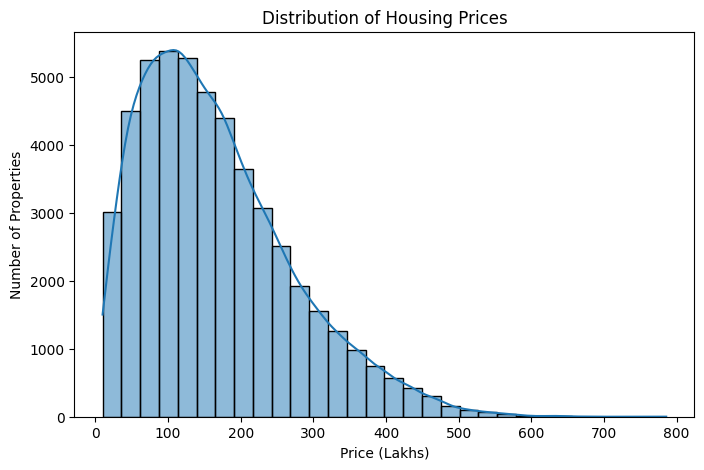

In [14]:
plt.figure(figsize=(8,5))
sns.histplot(df["price_in_lakhs"], bins=30, kde=True)
plt.title("Distribution of Housing Prices")
plt.xlabel("Price (Lakhs)")
plt.ylabel("Number of Properties")
plt.show()

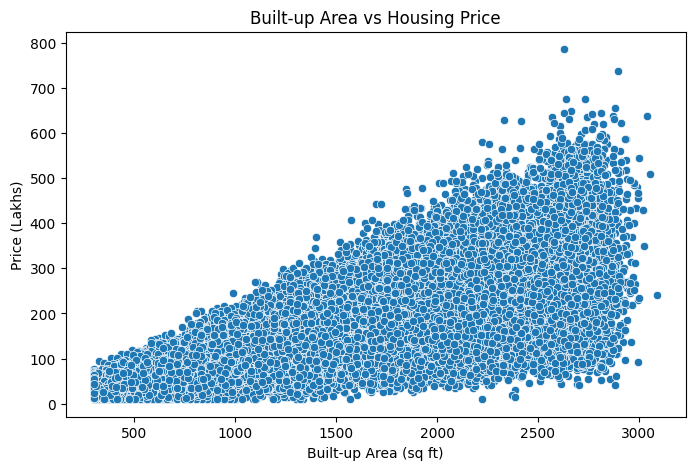

In [15]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x=df["built_up_area"],
    y=df["price_in_lakhs"]
)

plt.title("Built-up Area vs Housing Price")
plt.xlabel("Built-up Area (sq ft)")
plt.ylabel("Price (Lakhs)")
plt.show()

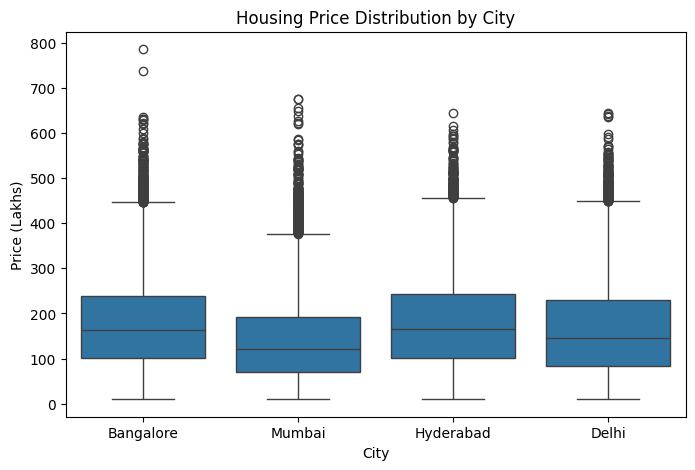

In [16]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="city",
    y="price_in_lakhs",
    data=df
)

plt.title("Housing Price Distribution by City")
plt.xlabel("City")
plt.ylabel("Price (Lakhs)")
plt.show()

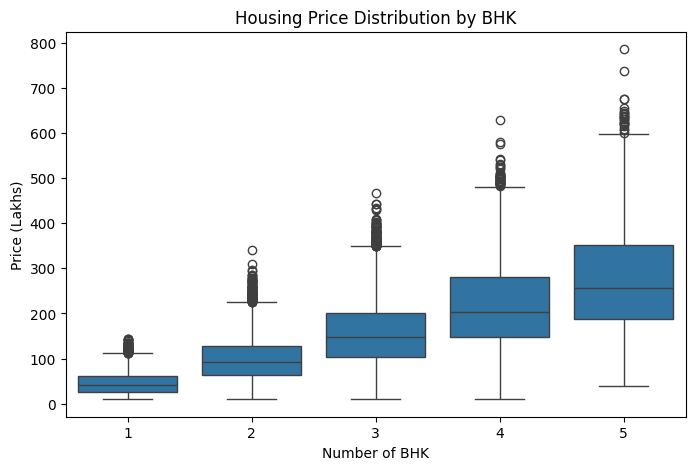

In [17]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="bhk",
    y="price_in_lakhs",
    data=df
)

plt.title("Housing Price Distribution by BHK")
plt.xlabel("Number of BHK")
plt.ylabel("Price (Lakhs)")
plt.show()

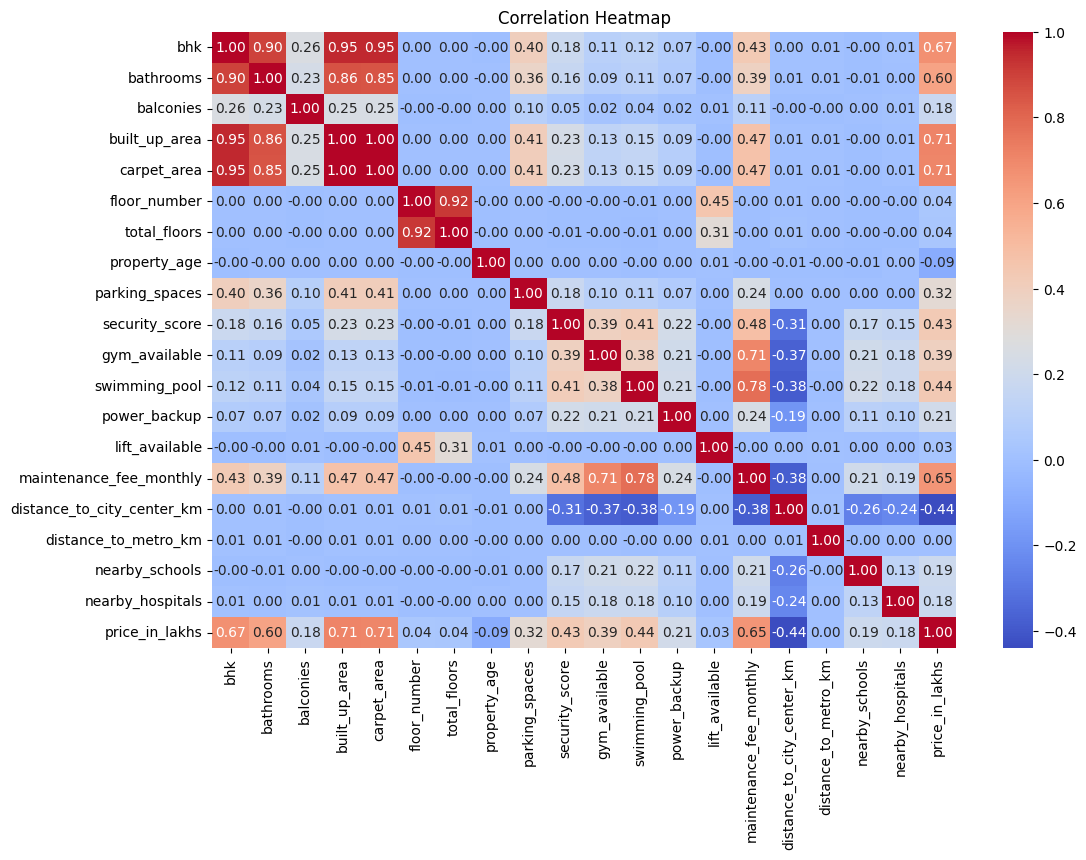

In [18]:
plt.figure(figsize=(12,8))

sns.heatmap(
    df.select_dtypes(include="number").corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

In [19]:
df.columns.tolist()

['property_id',
 'city',
 'locality',
 'locality_tier',
 'property_type',
 'bhk',
 'bathrooms',
 'balconies',
 'built_up_area',
 'carpet_area',
 'floor_number',
 'total_floors',
 'floor_category',
 'facing',
 'furnishing_status',
 'property_age',
 'parking_spaces',
 'security_score',
 'gym_available',
 'swimming_pool',
 'power_backup',
 'lift_available',
 'maintenance_fee_monthly',
 'distance_to_city_center_km',
 'distance_to_metro_km',
 'nearby_schools',
 'nearby_hospitals',
 'transaction_type',
 'price_in_lakhs',
 'price_category']

In [22]:
df["area_per_bhk"] = df["built_up_area"] / df["bhk"]

df["amenity_score"] = (
    df["gym_available"]
    + df["swimming_pool"]
    + df["power_backup"]
    + df["lift_available"]
)

In [23]:
df[["built_up_area", "bhk", "area_per_bhk", "amenity_score"]].head()

,built_up_area,bhk,area_per_bhk,amenity_score
0,1570,4,392.500000,1
1,908,2,454.000000,3
2,1784,3,594.666667,4
3,2318,4,579.500000,1
4,988,3,329.333333,2


In [24]:
df_model = df.drop(columns=["property_id", "price_in_lakhs", "price_category"])

In [25]:
X = df_model
y = df["price_in_lakhs"]

In [26]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (50000, 29)
y shape: (50000,)


In [27]:
print("Categorical columns:")
print(X.select_dtypes(include="object").columns.tolist())

print("\nNumerical columns:")
print(X.select_dtypes(exclude="object").columns.tolist())

Categorical columns:
['city', 'locality', 'locality_tier', 'property_type', 'floor_category', 'facing', 'furnishing_status', 'transaction_type']

Numerical columns:
['bhk', 'bathrooms', 'balconies', 'built_up_area', 'carpet_area', 'floor_number', 'total_floors', 'property_age', 'parking_spaces', 'security_score', 'gym_available', 'swimming_pool', 'power_backup', 'lift_available', 'maintenance_fee_monthly', 'distance_to_city_center_km', 'distance_to_metro_km', 'nearby_schools', 'nearby_hospitals', 'area_per_bhk', 'amenity_score']


In [28]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

In [29]:
categorical_cols = X.select_dtypes(include="object").columns.tolist()
numerical_cols = X.select_dtypes(exclude="object").columns.tolist()

In [31]:
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
        ("num", "passthrough", numerical_cols)
    ]
)

In [32]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42
)

In [33]:
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    random_state=42
)

In [34]:
print("Training data:", X_train.shape)
print("Validation data:", X_val.shape)
print("Testing data:", X_test.shape)

Training data: (40000, 29)
Validation data: (5000, 29)
Testing data: (5000, 29)


In [35]:
X_train_processed = preprocessor.fit_transform(X_train)

In [36]:
X_val_processed = preprocessor.transform(X_val)
X_test_processed = preprocessor.transform(X_test)

In [37]:
print("Training processed:", X_train_processed.shape)
print("Validation processed:", X_val_processed.shape)
print("Testing processed:", X_test_processed.shape)

Training processed: (40000, 72)
Validation processed: (5000, 72)
Testing processed: (5000, 72)


In [38]:
from sklearn.linear_model import LinearRegression

In [39]:
lr_model = LinearRegression()

In [40]:
lr_model.fit(X_train_processed, y_train)

LinearRegression()

In [44]:
y_val_pred_lr = lr_model.predict(X_val_processed)

In [45]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [46]:
mae_lr = mean_absolute_error(y_val, y_val_pred_lr)

rmse_lr = np.sqrt(mean_squared_error(y_val, y_val_pred_lr))

r2_lr = r2_score(y_val, y_val_pred_lr)

In [47]:
print("Linear Regression Results")
print("MAE :", mae_lr)
print("RMSE:", rmse_lr)
print("R² Score:", r2_lr)

Linear Regression Results
MAE : 33.77070711354263
RMSE: 44.34573036204724
R² Score: 0.8189471296147762


In [48]:
from sklearn.tree import DecisionTreeRegressor

In [49]:
dt_model = DecisionTreeRegressor(
    random_state=42,
    max_depth=10
)

In [50]:
dt_model.fit(X_train_processed, y_train)

DecisionTreeRegressor(max_depth=10, random_state=42)

In [51]:
y_val_pred_dt = dt_model.predict(X_val_processed)

In [52]:
mae_dt = mean_absolute_error(y_val, y_val_pred_dt)

rmse_dt = np.sqrt(mean_squared_error(y_val, y_val_pred_dt))

r2_dt = r2_score(y_val, y_val_pred_dt)

In [53]:
print("Decision Tree Results")
print("MAE :", mae_dt)
print("RMSE:", rmse_dt)
print("R² Score:", r2_dt)

Decision Tree Results
MAE : 29.45913230876272
RMSE: 40.780779114405505
R² Score: 0.8468867313680428


In [54]:
from sklearn.ensemble import RandomForestRegressor

In [55]:
rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=15,
    random_state=42,
    n_jobs=-1
)

In [56]:
rf_model.fit(X_train_processed, y_train)

RandomForestRegressor(max_depth=15, n_jobs=-1, random_state=42)

In [57]:
y_val_pred_rf = rf_model.predict(X_val_processed)

In [58]:
mae_rf = mean_absolute_error(y_val, y_val_pred_rf)

rmse_rf = np.sqrt(mean_squared_error(y_val, y_val_pred_rf))

r2_rf = r2_score(y_val, y_val_pred_rf)

In [59]:
print("Random Forest Results")
print("MAE :", mae_rf)
print("RMSE:", rmse_rf)
print("R² Score:", r2_rf)

Random Forest Results
MAE : 27.278211501132347
RMSE: 37.61170092779273
R² Score: 0.8697589950253599


In [60]:
y_test_pred_rf = rf_model.predict(X_test_processed)

In [61]:
mae_test = mean_absolute_error(y_test, y_test_pred_rf)

rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred_rf))

r2_test = r2_score(y_test, y_test_pred_rf)

In [62]:
print("Random Forest - Final Test Results")
print("MAE :", mae_test)
print("RMSE:", rmse_test)
print("R² Score:", r2_test)

Random Forest - Final Test Results
MAE : 27.43148719703895
RMSE: 37.48623253792219
R² Score: 0.8706043386795116


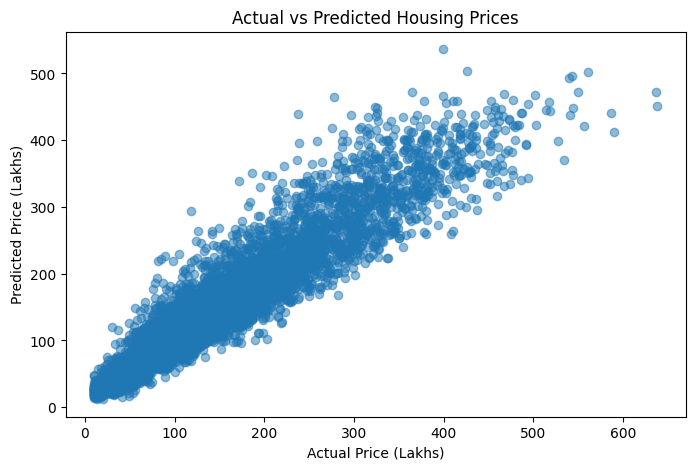

In [63]:
plt.figure(figsize=(8,5))

plt.scatter(y_test, y_test_pred_rf, alpha=0.5)

plt.xlabel("Actual Price (Lakhs)")
plt.ylabel("Predicted Price (Lakhs)")
plt.title("Actual vs Predicted Housing Prices")

plt.show()

In [65]:
feature_names = preprocessor.get_feature_names_out()

importances = rf_model.feature_importances_

feature_importance = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values("importance", ascending=False)

feature_importance.head(15)

,feature,importance
54,num__built_up_area,0.523490
25,cat__locality_tier_Premium,0.307484
55,num__carpet_area,0.023333
26,cat__locality_tier_Standard,0.021395
58,num__property_age,0.017231
24,cat__locality_tier_Affordable,0.013788
65,num__maintenance_fee_monthly,0.010576
60,num__security_score,0.007900
66,num__distance_to_city_center_km,0.007107
67,num__distance_to_metro_km,0.006520


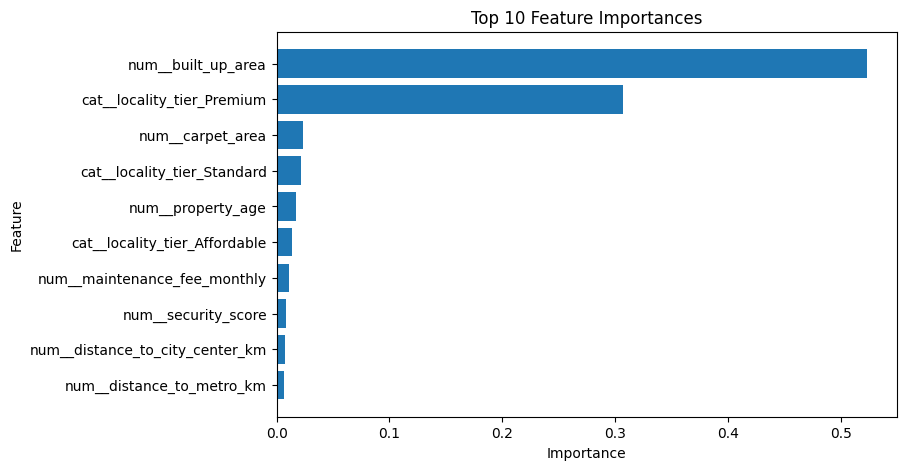

In [66]:
top_features = feature_importance.head(10).sort_values("importance")

plt.figure(figsize=(8,5))
plt.barh(top_features["feature"], top_features["importance"])
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 10 Feature Importances")
plt.show()

In [68]:
new_house = pd.DataFrame({
    "city": ["Bangalore"],
    "locality": ["Whitefield"],
    "locality_tier": ["Premium"],
    "property_type": ["Apartment"],
    "bhk": [3],
    "bathrooms": [3],
    "balconies": [2],
    "built_up_area": [1500],
    "carpet_area": [1250],
    "floor_number": [8],
    "total_floors": [15],
    "floor_category": ["Mid Floor"],
    "facing": ["East"],
    "furnishing_status": ["Fully Furnished"],
    "property_age": [5],
    "parking_spaces": [1],
    "security_score": [8],
    "gym_available": [1],
    "swimming_pool": [1],
    "power_backup": [1],
    "lift_available": [1],
    "maintenance_fee_monthly": [5000],
    "distance_to_city_center_km": [12],
    "distance_to_metro_km": [2],
    "nearby_schools": [5],
    "nearby_hospitals": [4],
    "transaction_type": ["Resale"]
})

In [69]:
new_house["area_per_bhk"] = (
    new_house["built_up_area"] / new_house["bhk"]
)

new_house["amenity_score"] = (
    new_house["gym_available"]
    + new_house["swimming_pool"]
    + new_house["power_backup"]
    + new_house["lift_available"]
)

new_house[["area_per_bhk", "amenity_score"]]

,area_per_bhk,amenity_score
0,500.0,4


In [70]:
new_house_processed = preprocessor.transform(new_house)

print("Processed shape:", new_house_processed.shape)

Processed shape: (1, 72)


In [71]:
predicted_price = rf_model.predict(new_house_processed)

print("Predicted House Price:", round(predicted_price[0], 2), "Lakhs")

Predicted House Price: 227.12 Lakhs
